In [1]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.metrics import accuracy_score


In [2]:
X,y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes = 2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

In [3]:
import matplotlib.pyplot as plt

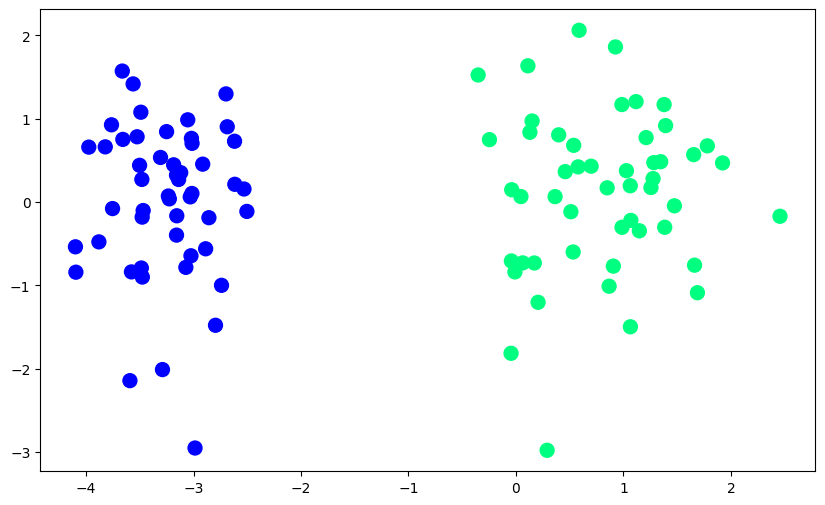

In [4]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [11]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')


In [12]:
lor.fit(X,y)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(penalty=None, solver='sag')

In [13]:
print(lor.coef_)
print(lor.intercept_)

[[4.82800013 0.22115164]]
[5.79630788]


In [14]:
ml = (-lor.coef_[0][0]/lor.coef_[0][1])
bc = (-lor.intercept_/lor.coef_[0][1])

In [15]:
x_input = np.linspace(-3,3,100)
y_input = ml*x_input + bc

In [16]:
X

array([[ 0.51123145, -0.11697552],
       [ 0.06316371, -0.73115232],
       [-0.0425064 , -0.7081059 ],
       [-3.2891569 , -2.01199214],
       [ 0.1111445 ,  1.63493163],
       [-2.53070306,  0.15599044],
       [-3.49036198,  1.07782053],
       [ 0.3976447 ,  0.80626713],
       [-0.24666899,  0.74859527],
       [-3.65803446,  0.75152794],
       [-3.47658131, -0.90114581],
       [-3.47815037, -0.1815243 ],
       [ 0.29004249, -2.98092432],
       [ 1.11761831,  1.20500136],
       [-3.52530398,  0.78302407],
       [ 0.69929128,  0.42968688],
       [ 0.17089733, -0.73229726],
       [-3.57785124, -0.83930476],
       [ 0.12965489,  0.83727062],
       [-3.46888717, -0.10255323],
       [-3.97487212,  0.65867001],
       [-3.76348686,  0.92649819],
       [-3.01519735,  0.10216193],
       [ 1.92241659,  0.46886454],
       [-2.91479578,  0.45432938],
       [ 0.9259563 ,  1.8613386 ],
       [-3.4859014 , -0.79255991],
       [-2.73978345, -1.0004391 ],
       [-4.09896768,

In [44]:
def gd(X,y):
  X = np.insert(X,0,1,axis = 1) #Adding col1 with each vslue = 1
  weights = np.ones(X.shape[1]) #Initializing weights with 1
  lr = 0.5

  for i in range(4500):
    y_hat = sigmoid(np.dot(X,weights))
    weights = weights + lr*(np.dot((y-y_hat),X)/X.shape[0])
  return weights[1:],weights[0]



In [45]:
def sigmoid(z):
  return 1/(1 + np.exp(-z))

In [46]:
coef_,np.intercept_ = gd(X,y)

In [47]:
m = -(coef_[0]/coef_[1])
b = -(np.intercept_/coef_[1])

In [48]:
x_input1 = np.linspace(-3,3,100)
y_input1 = m*x_input1 + b

(-3.0, 2.0)

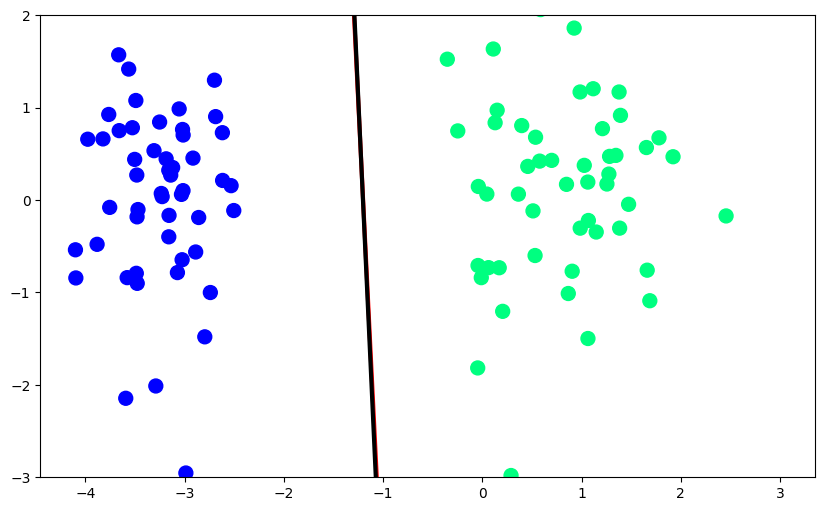

In [49]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color = 'red',linewidth = 3)
plt.plot(x_input1,y_input1,color = 'black',linewidth = 3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)